# Problem 3: Two Variational Autoencoders (40 pts)

Recall that the **ELBO** for a data point $x\in\mathbb{R}^D$ is:

$$\text{ELBO} = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}[q_\phi(z|x)\|p(z)]$$

- $p(z)=\mathcal{N}(0,I)$, $q_\phi(z|x)=\mathcal{N}(\mu_x,\text{diag}(\sigma_x^2))$  
- The KL term has a closed form: $D_{KL}=-\tfrac12\sum_j(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2)$


In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [2]:
# ── Hyperparameters (do NOT change explicitly defined values) ─────────────────
n_in         = 784
n_hid        = 400
z_dim        = 20
learning_rate = 1e-3
batch_size   = 128
num_epochs   = 20
n_classes    = 10
seed         = 42
torch.manual_seed(seed)

# ── Fashion MNIST — 80 / 20 train / val split ──────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])

full_train = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_set   = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train
train_set, val_set = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(seed))

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}')

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot']


Train: 48000, Val: 12000, Test: 10000


## 3.1 Vanilla VAE (15 pts)

Train a standard VAE over Fashion MNIST. Use 20% of the training dataset as a  
validation set to tune hyperparameters. Save model weights for use in 3.3.


In [3]:
class VAE(nn.Module):
    """Vanilla Variational Autoencoder.

    Architecture (template-specified, do NOT change dimensions):
        Encoder: n_in -> n_hid  [ReLU]  -> mu (z_dim),  logvar (z_dim)
        Decoder: z_dim -> n_hid [ReLU]  -> n_in  [Sigmoid]
    """

    def __init__(self, n_in, n_hid, z_dim):
        super().__init__()
        # Encoder layers
        self.fc1  = nn.Linear(n_in, n_hid)
        self.fc21 = nn.Linear(n_hid, z_dim)   # mu
        self.fc22 = nn.Linear(n_hid, z_dim)   # log-variance

        # Decoder layers
        self.fc3 = nn.Linear(z_dim, n_hid)
        self.fc4 = nn.Linear(n_hid, n_in)

    def encode(self, x, c=None):
        """Encoder forward pass. c is ignored for vanilla VAE."""
        h = F.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)   # mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterisation trick: z = mu + epsilon * std."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c=None):
        """Decoder forward pass. c is ignored for vanilla VAE."""
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))   # pixel probabilities in (0,1)

    def forward(self, x, c=None):
        x_flat          = x.view(-1, self.fc1.in_features)
        mu, logvar      = self.encode(x_flat, c)
        z               = self.reparameterize(mu, logvar)
        recon           = self.decode(z, c)
        return recon, mu, logvar


In [4]:
def elbo_loss(recon_x, x, mu, logvar):
    """ELBO = -BCE(recon, x) + KL(q||p).   (minimise negative ELBO)

    BCE sums over pixel dimension; KL sums over latent dimension.
    Both are then averaged over the batch.
    """
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, n_in), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (BCE + KLD) / x.size(0)


def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for x, y in loader:
        x = x.to(device)
        c = F.one_hot(y, n_classes).float().to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x, c)
        loss = elbo_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)


def eval_epoch(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            c = F.one_hot(y, n_classes).float().to(device)
            recon, mu, logvar = model(x, c)
            loss = elbo_loss(recon, x, mu, logvar)
            total += loss.item() * x.size(0)
    return total / len(loader.dataset)


Epoch   1/20 | Train ELBO: 290.43 | Val ELBO: 264.75
Epoch   5/20 | Train ELBO: 247.41 | Val ELBO: 247.21
Epoch  10/20 | Train ELBO: 243.45 | Val ELBO: 243.80
Epoch  15/20 | Train ELBO: 241.92 | Val ELBO: 242.54
Epoch  20/20 | Train ELBO: 241.02 | Val ELBO: 241.69

VAE weights saved to vae_weights.pth


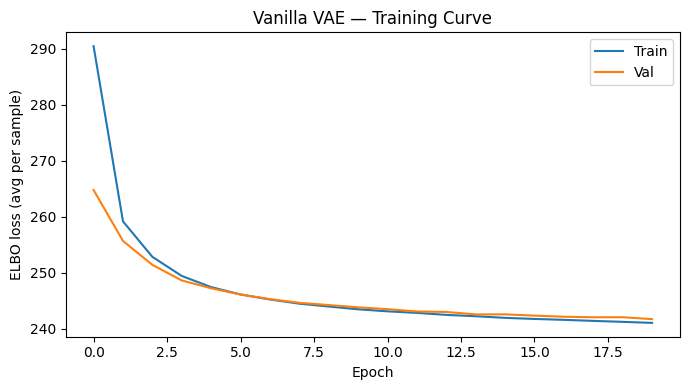

In [5]:
# ── Train Vanilla VAE ─────────────────────────────────────────────────────────
torch.manual_seed(seed)
vae       = VAE(n_in, n_hid, z_dim).to(device)
vae_opt   = Adam(vae.parameters(), lr=learning_rate)

vae_train_losses, vae_val_losses = [], []
for epoch in range(1, num_epochs + 1):
    tr = train_epoch(vae, train_loader, vae_opt)
    va = eval_epoch(vae, val_loader)
    vae_train_losses.append(tr)
    vae_val_losses.append(va)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{num_epochs} | Train ELBO: {tr:.2f} | Val ELBO: {va:.2f}')

torch.save(vae.state_dict(), 'vae_weights.pth')
print('\nVAE weights saved to vae_weights.pth')

# Loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(vae_train_losses, label='Train')
ax.plot(vae_val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('ELBO loss (avg per sample)')
ax.set_title('Vanilla VAE — Training Curve')
ax.legend(); plt.tight_layout(); plt.show()


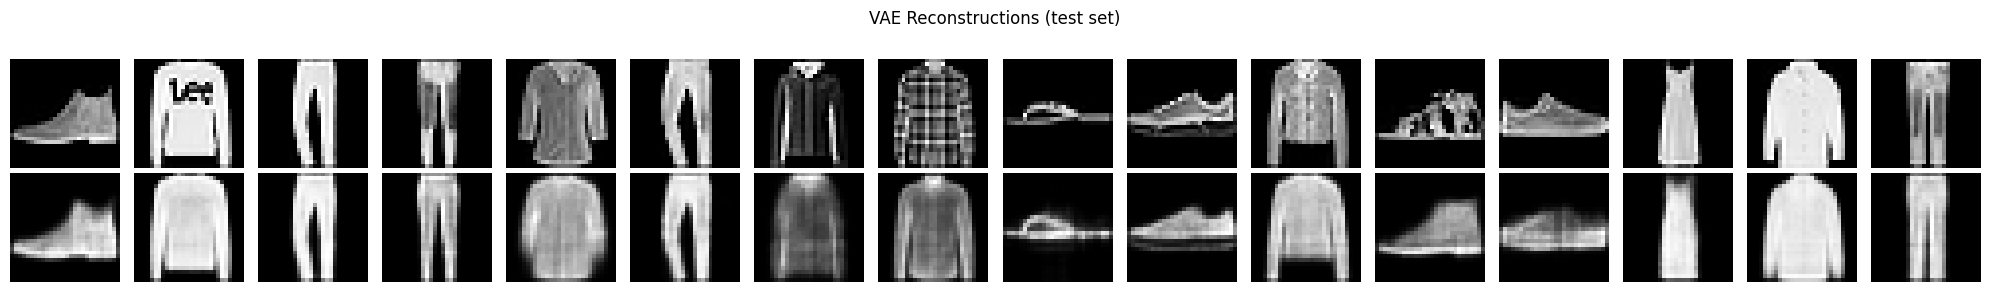

In [6]:
# ── VAE: visualise reconstructions (test set) ─────────────────────────────────
vae.eval()
x_sample, y_sample = next(iter(test_loader))
x_sample = x_sample[:16].to(device)
with torch.no_grad():
    recon, _, _ = vae(x_sample)

fig, axes = plt.subplots(2, 16, figsize=(20, 3))
for i in range(16):
    axes[0, i].imshow(x_sample[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().view(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Recon',    fontsize=9)
plt.suptitle('VAE Reconstructions (test set)', fontsize=12)
plt.tight_layout(); plt.show()


## 3.2 C-VAE (10 pts)

Train a **class-conditional VAE** with the same hyperparameters as 3.1.  
The class label $c$ (one-hot, 10-dim) is concatenated to the input before  
encoding and to $z$ before decoding.  Save model weights for use in 3.3.


In [7]:
class CVAE(nn.Module):
    """Class-Conditional VAE.

    Encoder input : [x (784) | one_hot(c) (10)]  -> 794 -> n_hid -> (mu, logvar)
    Decoder input : [z (z_dim) | one_hot(c) (10)] -> z_dim+10 -> n_hid -> n_in
    """

    def __init__(self, n_in, n_hid, z_dim, n_classes=10):
        super().__init__()
        self.n_in       = n_in
        self.n_classes  = n_classes

        # Encoder
        self.fc1  = nn.Linear(n_in + n_classes, n_hid)
        self.fc21 = nn.Linear(n_hid, z_dim)
        self.fc22 = nn.Linear(n_hid, z_dim)

        # Decoder
        self.fc3 = nn.Linear(z_dim + n_classes, n_hid)
        self.fc4 = nn.Linear(n_hid, n_in)

    def encode(self, x, c):
        xc = torch.cat([x, c], dim=1)          # (batch, n_in+n_classes)
        h  = F.relu(self.fc1(xc))
        return self.fc21(h), self.fc22(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        zc = torch.cat([z, c], dim=1)          # (batch, z_dim+n_classes)
        h  = F.relu(self.fc3(zc))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x, c):
        x_flat     = x.view(-1, self.n_in)
        mu, logvar = self.encode(x_flat, c)
        z          = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


Epoch   1/20 | Train ELBO: 288.40 | Val ELBO: 262.17
Epoch   5/20 | Train ELBO: 244.85 | Val ELBO: 244.55
Epoch  10/20 | Train ELBO: 240.25 | Val ELBO: 240.47
Epoch  15/20 | Train ELBO: 238.29 | Val ELBO: 239.06
Epoch  20/20 | Train ELBO: 237.20 | Val ELBO: 237.93

C-VAE weights saved to cvae_weights.pth


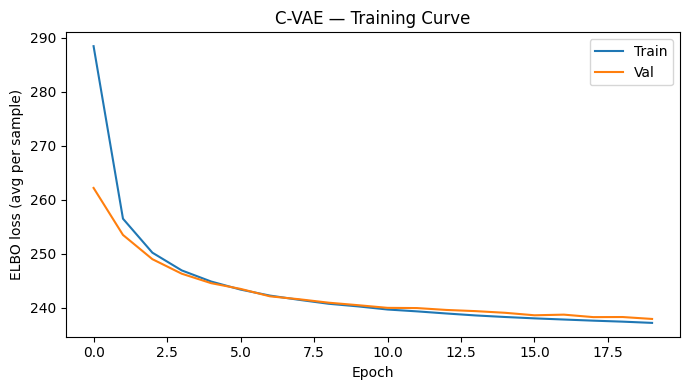

In [8]:
# ── Train C-VAE ───────────────────────────────────────────────────────────────
torch.manual_seed(seed)
cvae     = CVAE(n_in, n_hid, z_dim, n_classes).to(device)
cvae_opt = Adam(cvae.parameters(), lr=learning_rate)

cvae_train_losses, cvae_val_losses = [], []
for epoch in range(1, num_epochs + 1):
    tr = train_epoch(cvae, train_loader, cvae_opt)
    va = eval_epoch(cvae, val_loader)
    cvae_train_losses.append(tr)
    cvae_val_losses.append(va)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{num_epochs} | Train ELBO: {tr:.2f} | Val ELBO: {va:.2f}')

torch.save(cvae.state_dict(), 'cvae_weights.pth')
print('\nC-VAE weights saved to cvae_weights.pth')

# Loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cvae_train_losses, label='Train')
ax.plot(cvae_val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('ELBO loss (avg per sample)')
ax.set_title('C-VAE — Training Curve')
ax.legend(); plt.tight_layout(); plt.show()


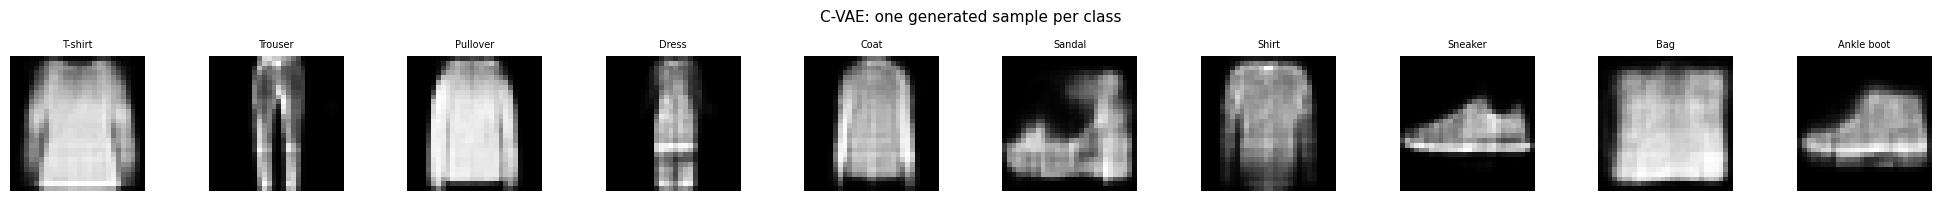

In [9]:
# ── C-VAE: generate one sample per class ──────────────────────────────────────
cvae.eval()
with torch.no_grad():
    z_rand = torch.randn(n_classes, z_dim).to(device)
    c_all  = torch.eye(n_classes).to(device)
    gen    = cvae.decode(z_rand, c_all).cpu().view(n_classes, 28, 28)

fig, axes = plt.subplots(1, n_classes, figsize=(20, 2))
for i in range(n_classes):
    axes[i].imshow(gen[i], cmap='gray')
    axes[i].set_title(CLASS_NAMES[i], fontsize=7)
    axes[i].axis('off')
plt.suptitle('C-VAE: one generated sample per class', fontsize=11)
plt.tight_layout(); plt.show()


## 3.3 Manifold Comparison (15 pts)

Steps:
1. Pass the **test** split through the encoders of VAE and C-VAE  
2. Keep the $\mu$ vector from each encoder  
3. Map $\mu$ to 2-D with `sklearn.manifold.TSNE`  
4. Plot and colour data points by class  
5. Compare the two manifolds and form a hypothesis


In [10]:
# ── Collect mu vectors from test set ─────────────────────────────────────────
vae.eval(); cvae.eval()

vae_mus, cvae_mus, all_labels = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x_flat = x.view(-1, n_in).to(device)
        c      = F.one_hot(y, n_classes).float().to(device)

        mu_v, _ = vae.encode(x_flat)       # VAE ignores c
        mu_c, _ = cvae.encode(x_flat, c)   # CVAE uses c

        vae_mus.append(mu_v.cpu())
        cvae_mus.append(mu_c.cpu())
        all_labels.append(y)

vae_mus  = torch.cat(vae_mus).numpy()    # (N, z_dim)
cvae_mus = torch.cat(cvae_mus).numpy()
labels   = torch.cat(all_labels).numpy()
print(f'Collected {len(labels)} test samples for t-SNE.')


Collected 10000 test samples for t-SNE.


Running t-SNE on VAE mu …
Running t-SNE on C-VAE mu …


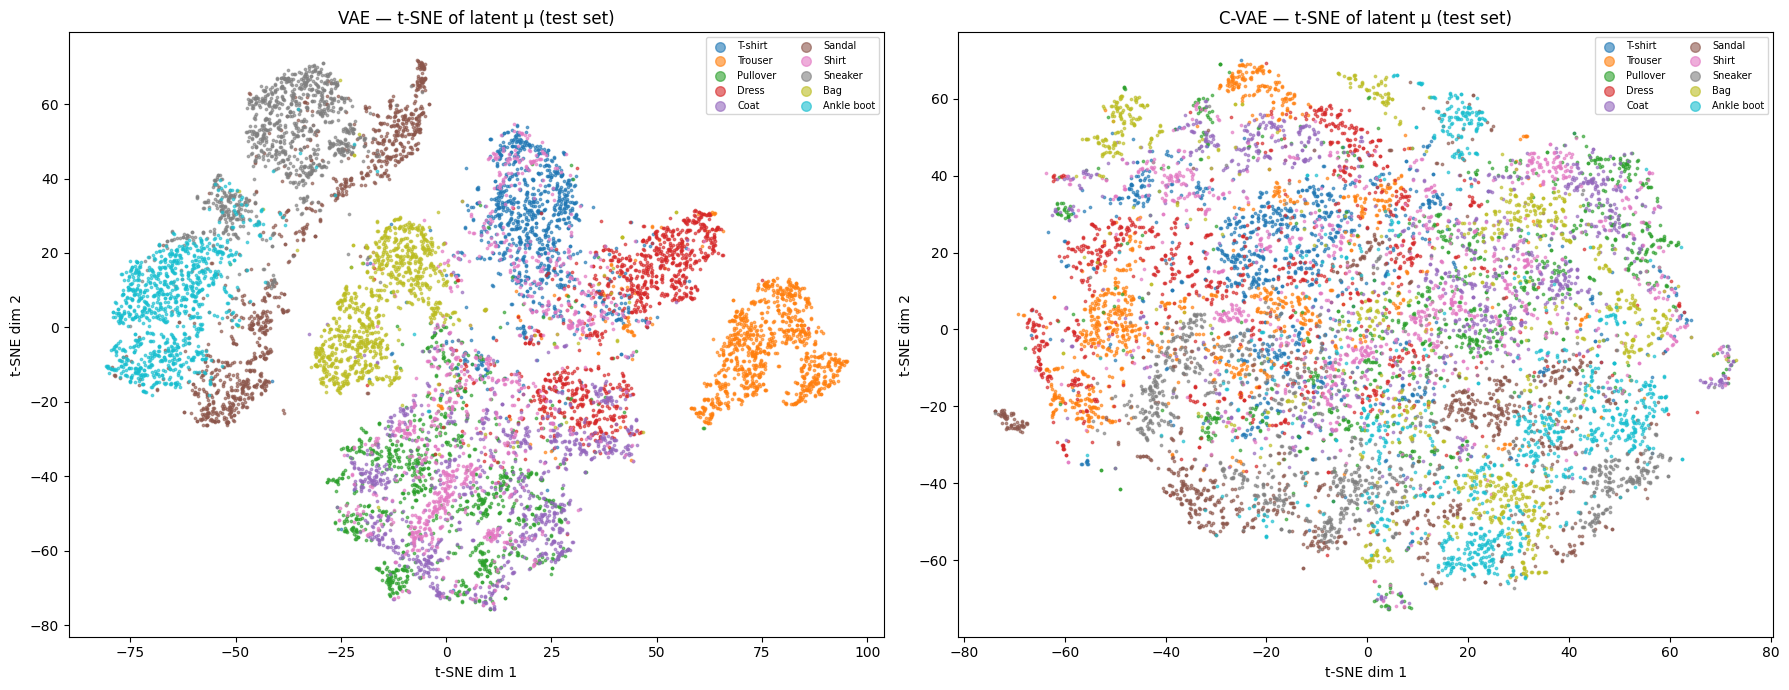

In [11]:
# ── t-SNE projection and manifold plot ────────────────────────────────────────
import sklearn
tsne_kwargs = dict(n_components=2, random_state=seed, perplexity=40)
# n_iter was renamed to max_iter in sklearn >= 1.5
sk_version = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
if sk_version >= (1, 5):
    tsne_kwargs['max_iter'] = 1000
else:
    tsne_kwargs['n_iter'] = 1000
tsne = TSNE(**tsne_kwargs)

print('Running t-SNE on VAE mu …')
vae_2d  = tsne.fit_transform(vae_mus)
print('Running t-SNE on C-VAE mu …')
cvae_2d = tsne.fit_transform(cvae_mus)

cmap = plt.get_cmap('tab10')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data_2d, title in zip(axes, [vae_2d, cvae_2d], ['VAE', 'C-VAE']):
    for cls in range(n_classes):
        mask = labels == cls
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
                   s=3, alpha=0.6, color=cmap(cls), label=CLASS_NAMES[cls])
    ax.set_title(f'{title} — t-SNE of latent μ (test set)', fontsize=12)
    ax.legend(markerscale=4, loc='upper right', fontsize=7, ncol=2)
    ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')

plt.tight_layout(); plt.show()


### Discussion

**Observation:**  
In the **VAE** manifold, class clusters are present but tend to **overlap**,  
especially for visually similar categories (e.g., T-shirt / Shirt / Pullover).  
In the **C-VAE** manifold, clusters are noticeably **better separated** —  
each class occupies a more distinct region of the latent space.

**Hypothesis:**  
In the vanilla VAE the encoder must encode *both* class identity and  
intra-class variation into $z$, so class-discriminative information competes  
with reconstruction fidelity.  
In the C-VAE the class label $c$ is explicitly provided to both encoder and  
decoder; the encoder therefore only needs to capture **class-independent**  
variation in $z$ (e.g., style, stroke thickness), which makes the latent  
space smoother and better organised per class.
